In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("Bibliotecas carregadas.")

Bibliotecas carregadas.


In [6]:
df = pd.read_csv('data/Sample - Superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [24]:
# Verificar o tamanho do dataset
print(f"Linhas e colunas: {df.shape}")

# Verificar valores nulos
print("\nValores nulos por coluna:")
print(df.isnull().sum())

# Remover duplicatas
df.drop_duplicates(inplace=True)

# Converter datas
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Criar coluna de Ano e Mês
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.to_period('M')

print("\nDados")
print(df.dtypes)

Linhas e colunas: (9994, 23)

Valores nulos por coluna:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Year             0
Month            0
dtype: int64

Dados
Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Cat

In [11]:
# Total de vendas
total_vendas = df['Sales'].sum()
print(f"Total de Vendas: $ {total_vendas:,.2f}")

# Total de lucro
total_lucro = df['Profit'].sum()
print(f"Total de Lucro: $ {total_lucro:,.2f}")

# Vendas por categoria
print("\nVendas por Categoria:")
print(df.groupby('Category')['Sales'].sum().sort_values(ascending=False))

# Lucro por região
print("\nLucro por Região:")
print(df.groupby('Region')['Profit'].sum().sort_values(ascending=False))

Total de Vendas: $ 2,297,200.86
Total de Lucro: $ 286,397.02

Vendas por Categoria:
Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

Lucro por Região:
Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


C:\Users\Gabriel\AppData\Local\Temp\ipykernel_15592\1458062827.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vendas_categoria.index, y=vendas_categoria.values, palette='viridis')


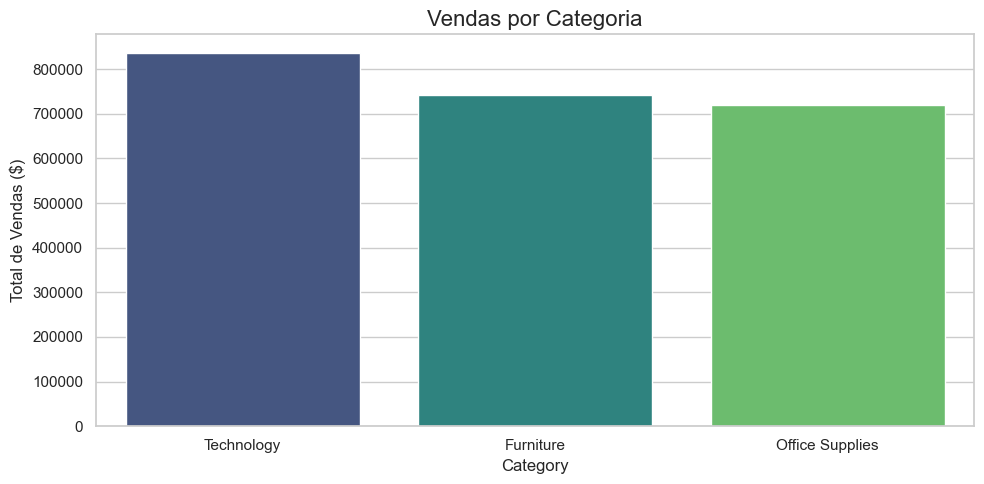

In [25]:
vendas_categoria = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=vendas_categoria.index, y=vendas_categoria.values, palette='viridis')
plt.title('Vendas por Categoria', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Total de Vendas ($)')
plt.tight_layout()
plt.show()

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_15592\1120232666.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lucro_regiao.index, y=lucro_regiao.values, palette='coolwarm')


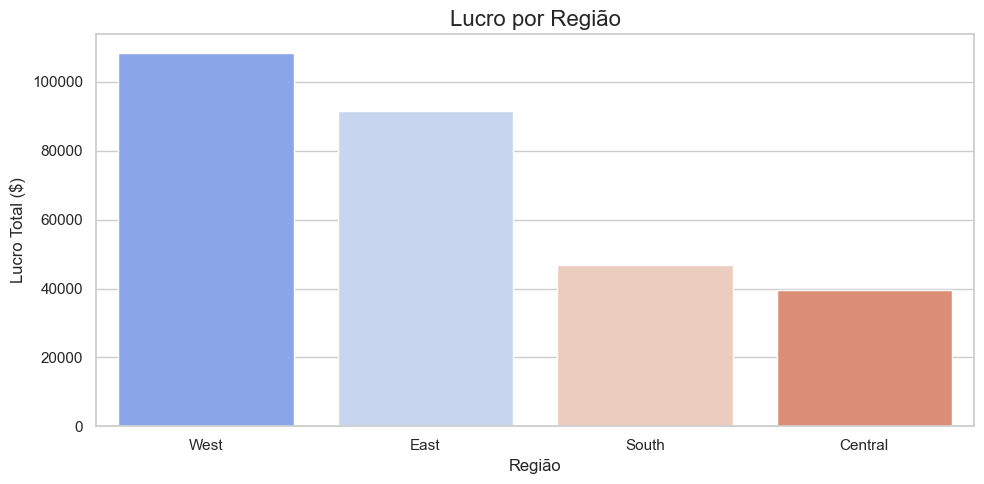

In [32]:
lucro_regiao = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=lucro_regiao.index, y=lucro_regiao.values, palette='coolwarm')
plt.title('Lucro por Região', fontsize=16)
plt.xlabel('Região')
plt.ylabel('Lucro Total ($)')
plt.tight_layout()
plt.show()

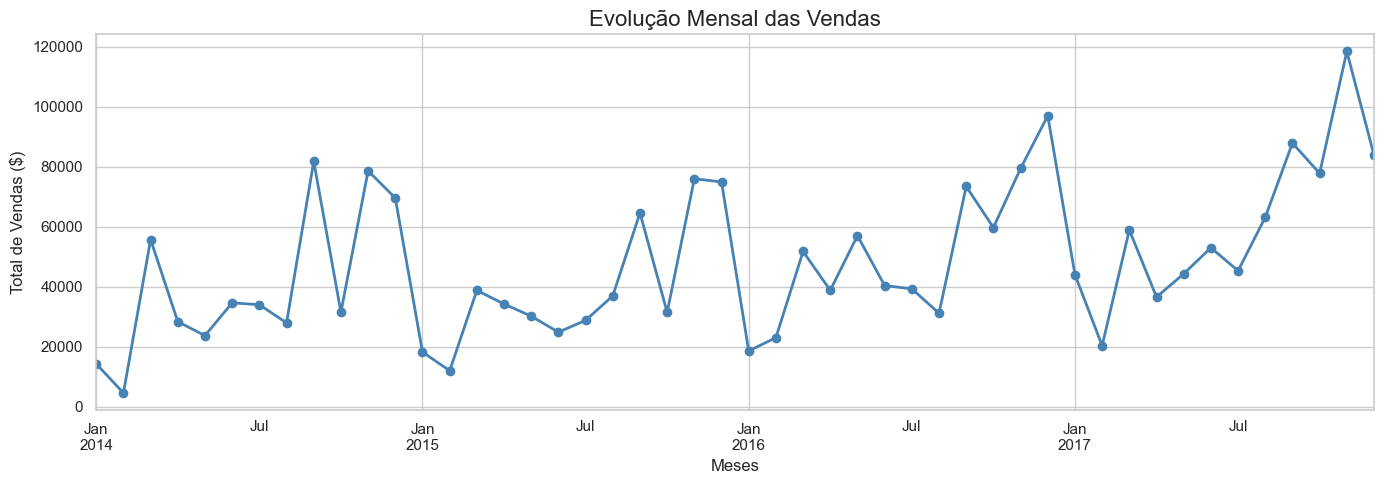

In [31]:
vendas_mes = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(14, 5))
vendas_mes.plot(kind='line', marker='o', color='steelblue', linewidth=2)
plt.title('Evolução Mensal das Vendas', fontsize=16)
plt.xlabel('Meses')
plt.ylabel('Total de Vendas ($)')
plt.tight_layout()
plt.show()

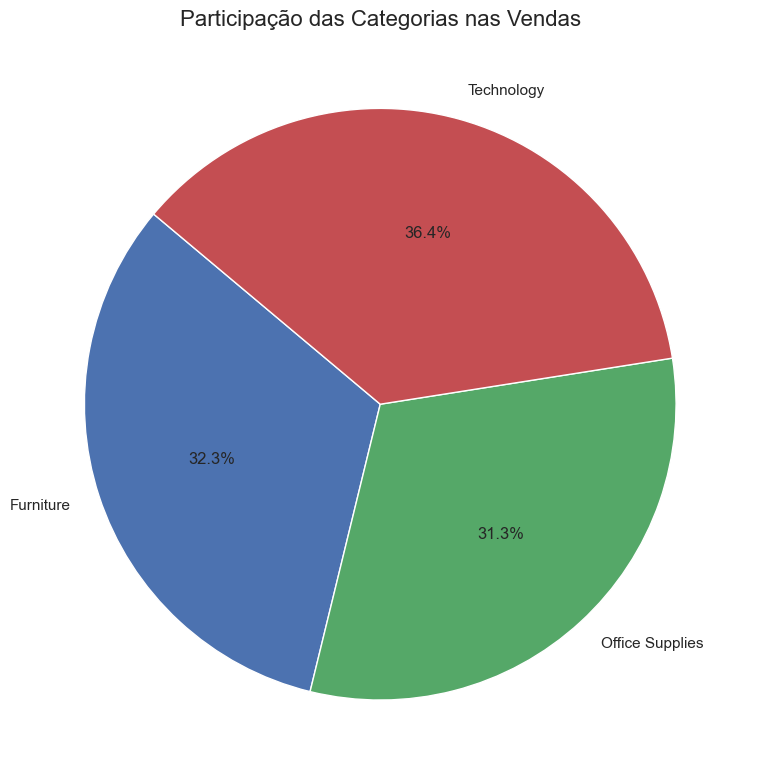

In [28]:
vendas_cat = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8, 8))
plt.pie(vendas_cat.values, labels=vendas_cat.index, autopct='%1.1f%%',
        colors=['#4C72B0', '#55A868', '#C44E52'], startangle=140)
plt.title('Participação das Categorias nas Vendas', fontsize=16)
plt.tight_layout()
plt.show()

In [30]:
# Calculando os dados para as conclusões
cat_top = df.groupby('Category')['Sales'].sum().idxmax()
regiao_top = df.groupby('Region')['Profit'].sum().idxmax()
vendas_por_ano = df.groupby('Year')['Sales'].sum()
crescimento = ((vendas_por_ano.iloc[-1] - vendas_por_ano.iloc[0]) / vendas_por_ano.iloc[0]) * 100

print("=" * 50)
print("        CONCLUSÕES DA ANÁLISE")
print("=" * 50)
print(f"\n📦 Categoria com maior faturamento: {cat_top}")
print(f"\n🌎 Região mais lucrativa: {regiao_top}")
print(f"\n📈 Crescimento de vendas no período: {crescimento:.1f}%")
print(f"\n💰 Total geral de vendas: $ {df['Sales'].sum():,.2f}")
print(f"\n💵 Total geral de lucro: $ {df['Profit'].sum():,.2f}")
print(f"\n🧾 Total de pedidos: {df['Order ID'].nunique()}")
print("\n" + "=" * 50)

        CONCLUSÕES DA ANÁLISE

📦 Categoria com maior faturamento: Technology

🌎 Região mais lucrativa: West

📈 Crescimento de vendas no período: 51.4%

💰 Total geral de vendas: $ 2,297,200.86

💵 Total geral de lucro: $ 286,397.02

🧾 Total de pedidos: 5009

